## 0. Imports

In [1]:
import numpy as np
from openalea.widgets.plantgl import *
from openalea.plantgl.all import Material, Color3, Scene

from openalea.archicrop.archicrop import ArchiCrop
from openalea.archicrop.display import build_scene, display_scene
import matplotlib.pyplot as plt
from openalea.archicrop.stand import agronomic_plot
from openalea.archicrop.light_it import illuminate, mean_leaf_irradiance
from openalea.astk.sky_irradiance import sky_irradiance
from openalea.astk.sky_sources import sky_sources, caribu_light_sources
from openalea.caribu.data_samples import data_path
nice_green=Color3((0,50,0))
%gui qt

## 1. Set management parameters

Set parameters regarding the spatial (and temporal) configuration of the crop.

In [2]:
inter_plant_m_m = 15
inter_plant_b_b = 5
inter_row_m_b = 25
inter_row_b_b = 15

density_ble = 1/(inter_plant_b_b*inter_row_b_b)
density_mais = 1/(inter_plant_m_m*inter_row_m_b)
print(density_ble)
print(density_mais)


#Coordonées de notre pattern :

x_mais = inter_row_m_b
y_mais = inter_plant_m_m * 1/2
z_mais = 0

coord_mais=(x_mais,y_mais,z_mais)

Xb1=[2*inter_row_m_b+(inter_row_b_b*k) for k in range (3)]
Yb1=[1/2*inter_plant_b_b+(inter_plant_b_b*k) for k in range (3)]


coord_ble=[]
for i in range (3):
    for j in range(3):
        coord_ble.append((Xb1[i],Yb1[j],0))
print (coord_ble)


0.013333333333333334
0.0026666666666666666
[(50, 2.5, 0), (50, 7.5, 0), (50, 12.5, 0), (65, 2.5, 0), (65, 7.5, 0), (65, 12.5, 0), (80, 2.5, 0), (80, 7.5, 0), (80, 12.5, 0)]


In [3]:
from openalea.plantgl.all import *
sphere_ble = Sphere(radius=1)
sphere_mais = Sphere(radius=2)
scene = Scene([Translated(pt, sphere_ble) for pt in coord_ble])
scene.add(Translated(coord_mais, sphere_mais))
PlantGL(scene)

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

Jour  T_moy   DJ     Total DJ   Thermique actif
1     12.5    12.5   12.5       0.0
2     9.3     9.3    21.8       0.0
3     13.2    13.2   35.0       0.0
4     17.6    17.6   52.6       0.0
5     8.8     8.8    61.5       0.0
6     8.8     8.8    70.3       0.0
7     17.9    17.9   88.2       0.0
8     13.8    13.8   102.0      13.8
9     7.7     7.7    109.7      21.5
10    12.7    12.7   122.4      34.2
...

✅ Temps thermique actif total (levée → maturité) : 2016.9 °C·j
📅 Nombre de jours de croissance active : 253


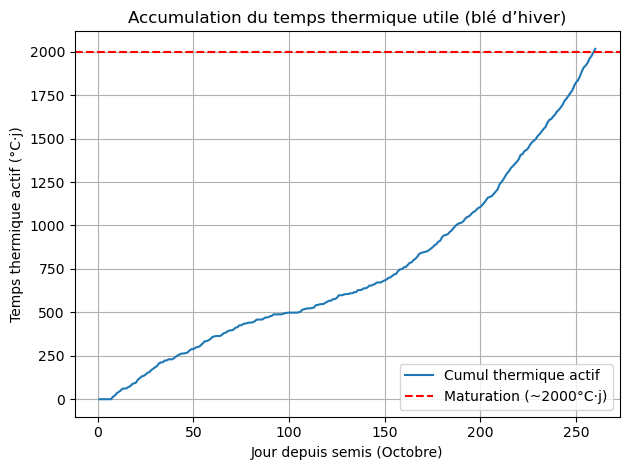

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 🌾 Paramètres agronomiques
temperature_base = 0           # Température de base du blé (°C)
seuil_levee = 100              # Seuil d’activation de la croissance (°C·j)
seuil_maturation = 2000        # Seuil de maturation (°C·j)

# 📅 Températures moyennes mensuelles approximées (région tempérée)
temp_moy_par_mois = {
    "Oct": 10, "Nov": 6, "Dec": 3, "Jan": 2, "Feb": 4,
    "Mar": 7, "Apr": 10, "May": 14, "Jun": 18, "Jul": 20
}
jours_par_mois = {
    "Oct": 31, "Nov": 30, "Dec": 31, "Jan": 31, "Feb": 28,
    "Mar": 31, "Apr": 30, "May": 31, "Jun": 30, "Jul": 15
}

# 🔁 Génération de températures journalières réalistes
np.random.seed(42)
temperature_moy_journalieres = []
for mois in ["Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul"]:
    moyenne = temp_moy_par_mois[mois]
    jours = jours_par_mois[mois]
    daily_temps = np.random.normal(loc=moyenne, scale=5.0, size=jours)
    temperature_moy_journalieres.extend(daily_temps)

# 📈 Calcul des degrés-jours et temps thermique actif
degres_jours = []
cumul_total = 0
cumul_actif = 0
croissance_active = False

for jour, t_moy in enumerate(temperature_moy_journalieres, start=1):
    dj = max(0, t_moy - temperature_base)
    cumul_total += dj

    if not croissance_active and cumul_total >= seuil_levee:
        croissance_active = True  # la plante commence à accumuler activement

    if croissance_active and cumul_actif < seuil_maturation:
        cumul_actif += dj

    degres_jours.append((jour, t_moy, dj, cumul_total, cumul_actif))

    if cumul_actif >= seuil_maturation:
        break  # la plante a atteint la maturité, on arrête

# 🖨️ Aperçu
print(f"{'Jour':<5} {'T_moy':<7} {'DJ':<6} {'Total DJ':<10} {'Thermique actif'}")
for jour, t_moy, dj, c_tot, c_actif in degres_jours[:10]:
    print(f"{jour:<5} {t_moy:<7.1f} {dj:<6.1f} {c_tot:<10.1f} {c_actif:.1f}")
print("...")
print(f"\n✅ Temps thermique actif total (levée → maturité) : {cumul_actif:.1f} °C·j")
print(f"📅 Nombre de jours de croissance active : {len([x for x in degres_jours if x[4] > 0])}")

# 📊 Graphique
jours = [j for j, _, _, _, _ in degres_jours]
cumuls_actifs = [c for _, _, _, _, c in degres_jours]

plt.plot(jours, cumuls_actifs, label="Cumul thermique actif")
plt.axhline(y=seuil_maturation, color='r', linestyle='--', label="Maturation (~2000°C·j)")
plt.xlabel("Jour depuis semis (Octobre)")
plt.ylabel("Temps thermique actif (°C·j)")
plt.title("Accumulation du temps thermique utile (blé d’hiver)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Jour  T_moy   DJ     Total DJ   Thermique actif
1     12.5    6.5    6.5        0.0
2     9.3     3.3    9.8        0.0
3     13.2    7.2    17.0       0.0
4     17.6    11.6   28.6       0.0
5     8.8     2.8    31.5       0.0
6     8.8     2.8    34.3       0.0
7     17.9    11.9   46.2       0.0
8     13.8    7.8    54.0       0.0
9     7.7     1.7    55.7       0.0
10    12.7    6.7    62.4       0.0
...

✅ Temps thermique actif total (levée → maturité) : 1414.7 °C·j
📅 Nombre de jours de croissance active : 118


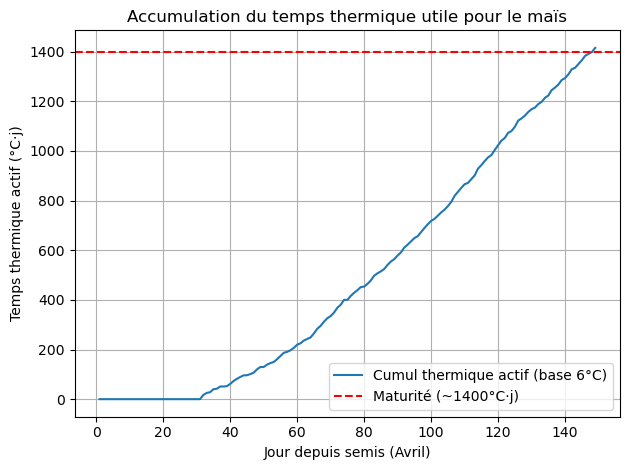

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 🌽 Paramètres agronomiques pour le maïs
temperature_base = 6             # Base thermique du maïs (°C)
seuil_levee = 120                # Levée vers 100–120 °C·j
seuil_maturation = 1400          # Maturité physiologique autour de 1400 °C·j

# 📅 Températures moyennes mensuelles approximatives (région tempérée)
temp_moy_par_mois = {
    "Apr": 10, "May": 14, "Jun": 18, "Jul": 21, "Aug": 20, "Sep": 17
}
jours_par_mois = {
    "Apr": 30, "May": 31, "Jun": 30, "Jul": 31, "Aug": 31, "Sep": 15  # Moisson mi-septembre
}

# 🔁 Génération de températures journalières avec variations
np.random.seed(42)
temperature_moy_journalieres = []
for mois in ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]:
    moyenne = temp_moy_par_mois[mois]
    jours = jours_par_mois[mois]
    daily_temps = np.random.normal(loc=moyenne, scale=5.0, size=jours)
    temperature_moy_journalieres.extend(daily_temps)

# 📈 Calcul des degrés-jours et temps thermique actif
degres_jours = []
cumul_total = 0
cumul_actif = 0
croissance_active = False

for jour, t_moy in enumerate(temperature_moy_journalieres, start=1):
    dj = max(0, t_moy - temperature_base)
    cumul_total += dj

    if not croissance_active and cumul_total >= seuil_levee:
        croissance_active = True  # début croissance active

    if croissance_active and cumul_actif < seuil_maturation:
        cumul_actif += dj

    degres_jours.append((jour, t_moy, dj, cumul_total, cumul_actif))

    if cumul_actif >= seuil_maturation:
        break  # maturité atteinte

# 🖨️ Aperçu
print(f"{'Jour':<5} {'T_moy':<7} {'DJ':<6} {'Total DJ':<10} {'Thermique actif'}")
for jour, t_moy, dj, c_tot, c_actif in degres_jours[:10]:
    print(f"{jour:<5} {t_moy:<7.1f} {dj:<6.1f} {c_tot:<10.1f} {c_actif:.1f}")
print("...")
print(f"\n✅ Temps thermique actif total (levée → maturité) : {cumul_actif:.1f} °C·j")
print(f"📅 Nombre de jours de croissance active : {len([x for x in degres_jours if x[4] > 0])}")

# 📊 Graphique
jours = [j for j, _, _, _, _ in degres_jours]
cumuls_actifs = [c for _, _, _, _, c in degres_jours]

plt.plot(jours, cumuls_actifs, label=f"Cumul thermique actif (base {temperature_base}°C)")
plt.axhline(y=seuil_maturation, color='r', linestyle='--', label="Maturité (~1400°C·j)")
plt.xlabel("Jour depuis semis (Avril)")
plt.ylabel("Temps thermique actif (°C·j)")
plt.title("Accumulation du temps thermique utile pour le maïs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


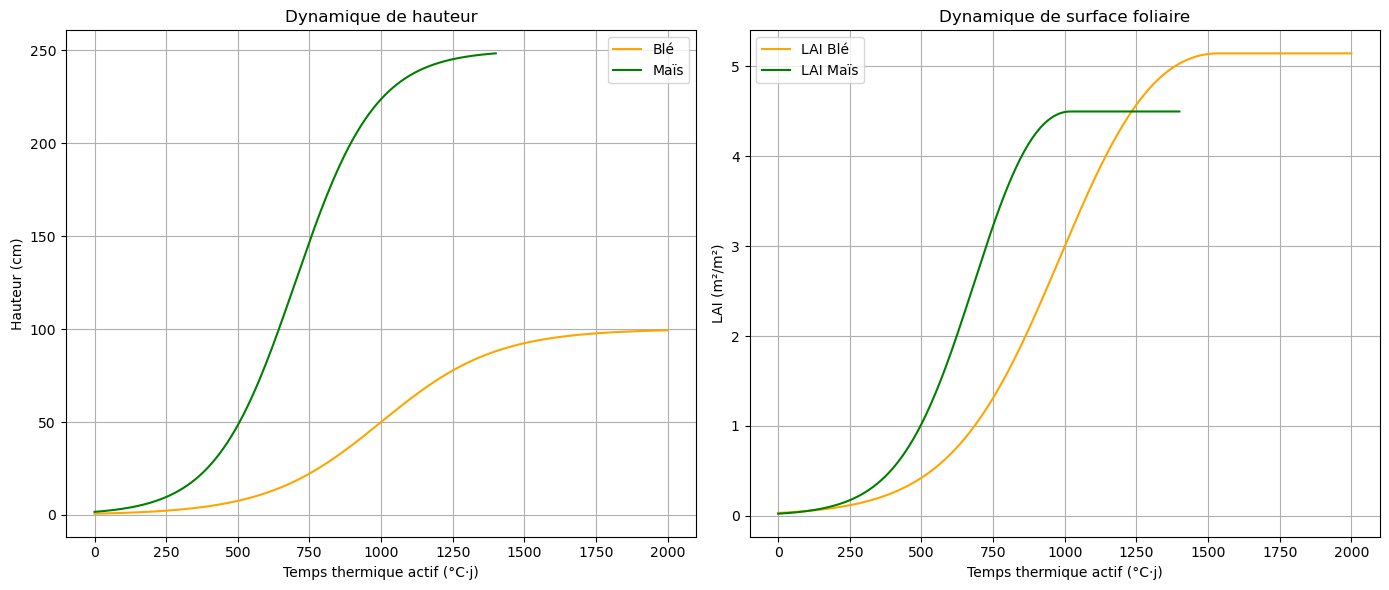

Exemple de surface foliaire par plante (m²/plante) à différents temps thermiques :
Blé TT=0 °C·j -> SF plante = 0.0002
Blé TT=500 °C·j -> SF plante = 0.0021
Blé TT=1000 °C·j -> SF plante = 0.0152
Blé TT=1500 °C·j -> SF plante = 0.0257
Blé TT=2000 °C·j -> SF plante = 0.0257
Maïs TT=0 °C·j -> SF plante = 0.0028
Maïs TT=350 °C·j -> SF plante = 0.0466
Maïs TT=700 °C·j -> SF plante = 0.3481
Maïs TT=1050 °C·j -> SF plante = 0.5624
Maïs TT=1400 °C·j -> SF plante = 0.5624


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres des espèces
ble_params = {
    'hauteur_max': 100,  # cm
    'lai_max': 6,
    'densite': 200,      # plantes/m²
    'tt_base': 0,
    'tt_total': 2000,
    'couleur': 'orange'
}

mais_params = {
    'hauteur_max': 250,  # cm
    'lai_max': 5.5,
    'densite': 8,        # plantes/m²
    'tt_base': 6,
    'tt_total': 1400,
    'couleur': 'green'
}

def facteur_lumiere_ble(tt_actif):
    # Facteur simple selon le temps thermique actif (temps dans l'année)
    # Le blé pousse en automne-hiver => facteur plus faible en hiver (par exemple)
    # On approxime par une fonction sinusoïdale entre 0.5 et 1
    return 0.75 + 0.25 * np.sin(np.pi * tt_actif / ble_params['tt_total'])

def facteur_lumiere_mais(tt_actif):
    # Le maïs pousse au printemps-été => facteur plus élevé en milieu de période
    return 0.6 + 0.4 * np.sin(np.pi * tt_actif / mais_params['tt_total'])

def croissance_sigmoide(tt_actif, tt_total, max_val):
    """Croissance sigmoïde simple en fonction du temps thermique actif"""
    r = 10 / tt_total  # taux ajusté pour que la courbe monte bien
    t0 = tt_total / 2  # milieu de la croissance
    return max_val / (1 + np.exp(-r * (tt_actif - t0)))

def dynamique_croissance(espece_params, facteur_lumiere_func):
    tt_total = espece_params['tt_total']
    tt_actif = np.linspace(0, tt_total, 200)
    
    # Hauteur sans facteur lumière
    hauteur = croissance_sigmoide(tt_actif, tt_total, espece_params['hauteur_max'])
    # Surface foliaire (LAI)
    lai = croissance_sigmoide(tt_actif, tt_total, espece_params['lai_max'])
    
    # Appliquer facteur lumière (modulation)
    facteur_lumiere = facteur_lumiere_func(tt_actif)
    lai_mod = lai * facteur_lumiere
    lai_mod = np.maximum.accumulate(lai_mod)  # Empêche la décroissance

    
    # Calcul surface foliaire par plante (m²/plante)
    sf_par_plante = lai_mod / espece_params['densite']
    
    return tt_actif, hauteur, lai_mod, sf_par_plante

# Calcul dynamique pour blé et maïs
tt_ble, hauteur_ble, lai_ble, sf_plante_ble = dynamique_croissance(ble_params, facteur_lumiere_ble)
tt_mais, hauteur_mais, lai_mais, sf_plante_mais = dynamique_croissance(mais_params, facteur_lumiere_mais)

# Graphiques
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(tt_ble, hauteur_ble, label='Blé', color=ble_params['couleur'])
plt.plot(tt_mais, hauteur_mais, label='Maïs', color=mais_params['couleur'])
plt.xlabel("Temps thermique actif (°C·j)")
plt.ylabel("Hauteur (cm)")
plt.title("Dynamique de hauteur")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(tt_ble, lai_ble, label='LAI Blé', color=ble_params['couleur'])
plt.plot(tt_mais, lai_mais, label='LAI Maïs', color=mais_params['couleur'])
plt.xlabel("Temps thermique actif (°C·j)")
plt.ylabel("LAI (m²/m²)")
plt.title("Dynamique de surface foliaire")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Impression de quelques valeurs exemples
print("Exemple de surface foliaire par plante (m²/plante) à différents temps thermiques :")
for tt in [0, int(0.25*ble_params['tt_total']), int(0.5*ble_params['tt_total']), int(0.75*ble_params['tt_total']), int(ble_params['tt_total'])]:
    idx = np.searchsorted(tt_ble, tt)
    print(f"Blé TT={tt} °C·j -> SF plante = {sf_plante_ble[idx]:.4f}")
for tt in [0, int(0.25*mais_params['tt_total']), int(0.5*mais_params['tt_total']), int(0.75*mais_params['tt_total']), int(mais_params['tt_total'])]:
    idx = np.searchsorted(tt_mais, tt)
    print(f"Maïs TT={tt} °C·j -> SF plante = {sf_plante_mais[idx]:.4f}")



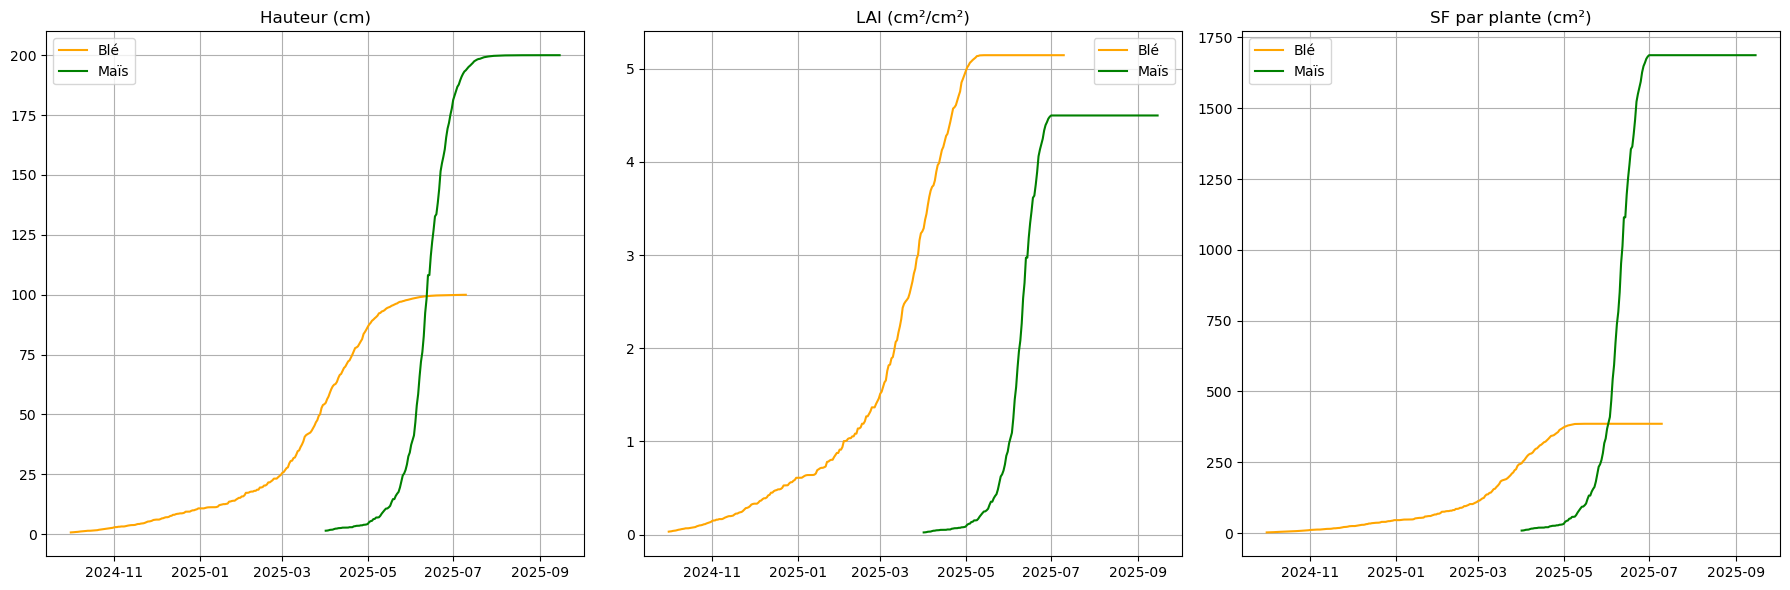


🌾 Surface foliaire par plante (cm²/plante)
Blé 2024-10-01 : SF = 2.4 cm²
Blé 2024-12-10 : SF = 30.0 cm²
Blé 2025-02-19 : SF = 95.2 cm²
Blé 2025-05-01 : SF = 373.3 cm²
Blé 2025-07-10 : SF = 386.0 cm²
Maïs 2025-04-01 : SF = 9.0 cm²
Maïs 2025-05-13 : SF = 86.9 cm²
Maïs 2025-06-24 : SF = 1570.9 cm²
Maïs 2025-08-05 : SF = 1687.2 cm²
Maïs 2025-09-15 : SF = 1687.2 cm²


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import datetime

# ------------------------------
# Espacement des plantes (m)
# ------------------------------
inter_plant_m_m = 0.15
inter_plant_b_b = 0.05
inter_row_m_b = 0.25
inter_row_b_b = 0.15

surface_par_plante_mais = inter_plant_m_m * inter_row_m_b
surface_par_plante_ble = inter_plant_b_b * inter_row_b_b

# ------------------------------
# Paramètres espèces
# ------------------------------
ble_params = {
    'hauteur_max': 100, 'lai_max': 6, 'densite': 1/surface_par_plante_ble,
    'tt_base': 0, 'tt_total': 2000, 'couleur': 'orange',
    'semis_date': datetime.date(2024, 10, 1)
}

mais_params = {
    'hauteur_max': 200, 'lai_max': 5.5, 'densite': 1/surface_par_plante_mais,
    'tt_base': 6, 'tt_total': 1000, 'couleur': 'green',
    'semis_date': datetime.date(2025, 4, 1)
}

# ------------------------------
# Température journalière
# ------------------------------
def generer_tt_journalier(start_date, mois_temps, jours_mois, base_temp):
    np.random.seed(42)
    jours, tts, cumul = [], [], 0
    current_day = start_date
    for mois in mois_temps:
        for _ in range(jours_mois[mois]):
            t = np.random.normal(mois_temps[mois], 5)
            dj = max(0, t - base_temp)
            cumul += dj
            jours.append(current_day)
            tts.append((cumul, dj))
            current_day += datetime.timedelta(days=1)
            if cumul > 2500: break
    return jours, tts

# Données climat
mois_ble = {"Oct":10, "Nov":6, "Dec":3, "Jan":2, "Feb":4, "Mar":7, "Apr":10, "May":14, "Jun":18, "Jul":20}
jours_ble = {"Oct":31, "Nov":30, "Dec":31, "Jan":31, "Feb":28, "Mar":31, "Apr":30, "May":31, "Jun":30, "Jul":15}
mois_mais = {"Apr":10, "May":14, "Jun":18, "Jul":21, "Aug":20, "Sep":17}
jours_mais = {"Apr":30, "May":31, "Jun":30, "Jul":31, "Aug":31, "Sep":15}

# ------------------------------
# Croissance
# ------------------------------
def facteur_lumiere(tt_actif, espece):
    if espece == 'ble':
        return 0.75 + 0.25 * np.sin(np.pi * tt_actif / ble_params['tt_total'])
    return 0.6 + 0.4 * np.sin(np.pi * tt_actif / mais_params['tt_total'])

def croissance_sigmoide(tt_actif, tt_total, max_val):
    r = 10 / tt_total
    t0 = tt_total / 2
    return max_val / (1 + np.exp(-r * (tt_actif - t0)))

def dynamique_croissance_tt(jours, tt_journalier, params, espece):
    tt = np.array([x[0] for x in tt_journalier])
    jours = jours[:len(tt)]
    hauteur = croissance_sigmoide(tt, params['tt_total'], params['hauteur_max'])
    lai = croissance_sigmoide(tt, params['tt_total'], params['lai_max'])
    facteur = facteur_lumiere(tt, espece)
    lai_mod = np.maximum.accumulate(lai * facteur)
    return jours, hauteur, lai_mod

def sf_journalier(jours, tt_journalier, params, espece):
    tt = np.array([x[0] for x in tt_journalier])
    lai = croissance_sigmoide(tt, params['tt_total'], params['lai_max'])
    facteur = facteur_lumiere(tt, espece)
    lai_mod = np.maximum.accumulate(lai * facteur)
    sf_par_plante = lai_mod / params['densite'] * 10000  # cm²/cm²
    return sf_par_plante

# ------------------------------
# Génération
# ------------------------------
jours_ble, tt_ble = generer_tt_journalier(ble_params['semis_date'], mois_ble, jours_ble, ble_params['tt_base'])
jours_mais, tt_mais = generer_tt_journalier(mais_params['semis_date'], mois_mais, jours_mais, mais_params['tt_base'])

jours_ble, hauteur_ble, lai_ble = dynamique_croissance_tt(jours_ble, tt_ble, ble_params, 'ble')
jours_mais, hauteur_mais, lai_mais = dynamique_croissance_tt(jours_mais, tt_mais, mais_params, 'mais')

sf_ble = sf_journalier(jours_ble, tt_ble, ble_params, 'ble')
sf_mais = sf_journalier(jours_mais, tt_mais, mais_params, 'mais')

# ------------------------------
# Affichage
# ------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].plot(jours_ble, hauteur_ble, label='Blé', color=ble_params['couleur'])
axes[0].plot(jours_mais, hauteur_mais, label='Maïs', color=mais_params['couleur'])
axes[0].set_title("Hauteur (cm)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(jours_ble, lai_ble, label='Blé', color=ble_params['couleur'])  # cm²/cm²
axes[1].plot(jours_mais, lai_mais, label='Maïs', color=mais_params['couleur'])
axes[1].set_title("LAI (cm²/cm²)")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(jours_ble, sf_ble, label='Blé', color=ble_params['couleur'])
axes[2].plot(jours_mais, sf_mais, label='Maïs', color=mais_params['couleur'])
axes[2].set_title("SF par plante (cm²)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# ------------------------------
# Impression
# ------------------------------
print("\n🌾 Surface foliaire par plante (cm²/plante)")
for idx in [0, int(len(sf_ble)*0.25), int(len(sf_ble)*0.5), int(len(sf_ble)*0.75), -1]:
    print(f"Blé {jours_ble[idx]} : SF = {sf_ble[idx]:.1f} cm²")
for idx in [0, int(len(sf_mais)*0.25), int(len(sf_mais)*0.5), int(len(sf_mais)*0.75), -1]:
    print(f"Maïs {jours_mais[idx]} : SF = {sf_mais[idx]:.1f} cm²")





## 2. Format crop-scale growth and senescence dynamics - optional ?

From crop-scale data either measured or simulated with a crop model, generate a dictionnary of dictionnaries for each day with the following values :
 - "Thermal time" (float): cumulated thermal time from beginning of simulation to current day (in °C.day)
 - "Phenology" (str): current phenological stage (germination, juvenile, exponential or repro)
 - "Plant leaf area" (float): plant leaf area (in cm²) 
 - "Leaf area increment" (float): leaf area increment compared to previous day (in cm²) 
 - "Plant senescent leaf area" (float): senescent plant leaf area (in cm²) 
 - "Senescent leaf area increment" (float): senescent leaf area increment compared to previous day (in cm²) 
 - "Plant height" (float): plant height (in cm) 
 - "Height increment" (float): height increment compared to previous day (in cm).

In [8]:
# Paramètres de phénologie (en jours après semis)
emergence = 0
end_juv = np.argmax(lai_ble)/2
jour_max_lai = np.argmax(lai_ble)  # position du LAI max en jours

# Création du dictionnaire de dynamique journalière pour le blé
daily_dynamics_ble = {
    i+1: {
        "Date": jours_ble[i],
        "Thermal time": tt_ble[i][0],
        "Thermal time increment": tt_ble[i][1],
        "Phenology": (
            'germination' if i+1 < emergence else
            'juvenile' if emergence <= i+1 < end_juv else
            'exponential' if end_juv <= i+1 < jour_max_lai else
            'repro'
        ),
        "Plant leaf area": sf_ble[i],  # surface foliaire par plante
        "Leaf area increment": sf_ble[i] - sf_ble[i-1] if i > 0 else sf_ble[i],
        "Plant senescent leaf area": 0,  # si non modélisée, on met 0
        "Senescent leaf area increment": 0,
        "Plant height": hauteur_ble[i],
        "Height increment": hauteur_ble[i] - hauteur_ble[i-1] if i > 0 else hauteur_ble[i]
    }
    for i in range(len(jours_ble))
}


emergence = 0
end_juv = np.argmax(lai_mais)/2
jour_max_lai = np.argmax(lai_mais)

daily_dynamics_mais = {
    i+1: {
        "Date": jours_mais[i],
        "Thermal time": tt_mais[i][0],
        "Thermal time increment": tt_mais[i][1],
        "Phenology": (
            'germination' if i+1 < emergence else
            'juvenile' if emergence <= i+1 < end_juv else
            'exponential' if end_juv <= i+1 < jour_max_lai else
            'repro'
        ),
        "Plant leaf area": sf_mais[i],
        "Leaf area increment": sf_mais[i] - sf_mais[i-1] if i > 0 else sf_mais[i],
        "Plant senescent leaf area": 0,
        "Senescent leaf area increment": 0,
        "Plant height": hauteur_mais[i],
        "Height increment": hauteur_mais[i] - hauteur_mais[i-1] if i > 0 else hauteur_mais[i]
    }
    for i in range(len(jours_mais))
}


## 3. Set plant architectural parameters

Set topological, geometrical and developmental parameters, in a range corresponding a given species, found in literature.

In [9]:

archi_ble = dict(
    nb_phy=10,  # phytomères typiques
    height=200,  # hauteur maximale en cm
    wl = 0.04,
    stem_q=1,  # distribution verticale de la hauteur
    diam_base=1.0,  # diamètre base tige (cm)
    diam_top=0.5,  # sommet

    leaf_area=1000,  # cm² environ par plante (~6 LAI / 250 plantes/m²)
    rmax=0.6,  # plus grande feuille vers 60% de la tige
    skew=0.001,  # distribution modérée

    insertion_angle=40,  # angle insertion feuille
    scurv=0.6,  # position point d’inflexion
    curvature=100,  # courbure plus modeste que maïs
    phyllotactic_angle=180,  # feuilles opposées ou faiblement hélicoïdales
    phyllotactic_deviation=15,

    phyllochron=100,
    # plastochron=40,

    leaf_lifespan=250,

    nb_tillers=4,
    tiller_delay=1,
    tiller_angle=15,
    reduction_factor=1,
)

archi_mais = dict(
    nb_phy=18,
    height=200,  # cm
    stem_q=1,
    wl = 0.14,
    diam_base=3,  # cm
    diam_top=1.5,

    leaf_area=2000,  # cm² par plante (~5.5 LAI / 8 plantes/m²)
    rmax=0.8,  # feuille la plus grande vers 80% de la tige
    skew=0.0003,  # distribution un peu plus étalée

    insertion_angle=50,
    scurv=0.7,
    curvature=120,
    phyllotactic_angle=180,
    phyllotactic_deviation=5,

    phyllochron=50,
    # plastochron=60,

    leaf_lifespan=400,

    nb_tillers=0,
    tiller_delay=0,
    tiller_angle=0,
    reduction_factor=1,
)





## 4. Instantiate ArchiCrop object

In [10]:

# 🌾 Création de la plante de blé
ble = ArchiCrop(
    daily_dynamics=daily_dynamics_ble,
    **archi_ble
)
ble.generate_potential_plant()

# 🌽 Création de la plante de maïs
mais = ArchiCrop(
    daily_dynamics=daily_dynamics_mais,
    **archi_mais
)
mais.generate_potential_plant()

print(ble)
print(mais)


## 5. Generate a potential plant 

Generate a potential plant from architectural parameters. 

This creates an MTG (Multi-scale Tree Graph, cf [doc](https://mtg.readthedocs.io/en/latest/user/tutorial.html)) as a property of the object plant.

In [11]:
mais.generate_potential_plant()

ble.generate_potential_plant()

## 6. Simulate growth and senescence of the plant

Simulate growth and senescence of this plant following the daily dynamics.

In [12]:
growing_mais = mais.grow_plant()


growing_ble = ble.grow_plant()

## 7. Plot 3D scene

In [13]:
# Extraire tous les temps thermiques cumulés
times = [cumul for i, (cumul, dj) in enumerate(tt_mais) if i%10==0]
mean_time = sum(times) / len(times)

# Position verticale centrée sur le temps thermique moyen
positions_mais = [(0, 1 * (t - mean_time), 0) for t in times]

nice_green = Color3((50, 100, 0))
scene, _ = build_scene([g for i,g in enumerate(list(growing_mais.values())) if i%10==0], position=positions_mais, senescence=True, leaf_material = Material(nice_green), stem_material=Material(nice_green))
PlantGL(scene)


Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

In [14]:
# Extraire tous les temps thermiques cumulés
times = [cumul for i, (cumul, dj) in enumerate(tt_ble) if i%10==0]
mean_time = sum(times) / len(times)

# Position verticale centrée sur le temps thermique moyen
positions_ble = [(0, 1 * (t - mean_time), 0) for t in times]

nice_green = Color3((50, 100, 0))
scene, _ = build_scene([g for i,g in enumerate(list(growing_ble.values())) if i%10==0], position=positions_ble, senescence=True, leaf_material = Material(nice_green), stem_material=Material(nice_green))
PlantGL(scene)

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

## Create scenes to compute light interception

For as many sowing dates differences as you want:  
    For n dates throughout the growing cycle:   
        1. Find the corresponding thermal time for each species  
        2. Find the corresponding graphs in growing_plant dict = {thermal time : graph} (to get graph: growing_plant\[thermal_time\])  
        3. Build the scene with positions previously determined (if no graph because the plant is not there yet  or anymore, )  
        4. Compute light interception on the scene  
        5. Get the evolution of light intercepted by both crops  
        6. Interpolate to get synthetic daily values of light intercepted by both crops  
        7. Compute the yield (= 0.02 * sum_of_intercepted_PAR_through_growth_cycle * RUE * harvest_index) and price of each crop  

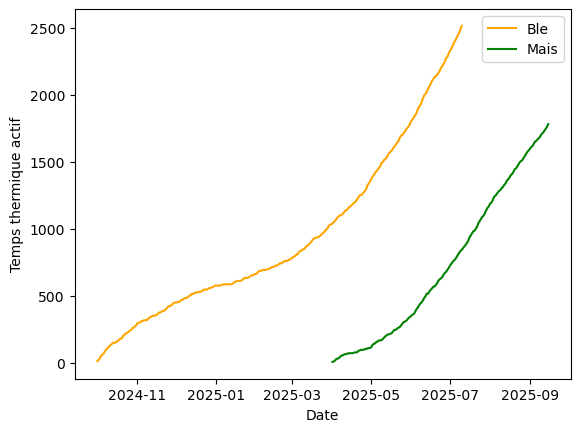

In [15]:
plt.plot(jours_ble, [tt[0] for tt in tt_ble], color="orange", label="Ble")
plt.plot(jours_mais, [tt[0] for tt in tt_mais], color="green", label="Mais")
plt.xlabel("Date")
plt.ylabel("Temps thermique actif")
plt.legend()
plt.show()

In [16]:
delta_sowing = jours_mais[0] - jours_ble[0]
delta_sowing = delta_sowing.days
delta_sowing

182

In [17]:
len(jours_mais)

168

In [18]:
len(jours_ble)

283

In [19]:
growing_cycle_intercrop = len(jours_mais) + delta_sowing
growing_cycle_intercrop

350

In [20]:
dates = [i for i in range(growing_cycle_intercrop) if i%20==0]
len(dates)

18

In [21]:
positions = [coord_mais] + coord_ble
domain = ((0, 0), (2*inter_row_m_b + 2*inter_row_b_b, 3*inter_plant_b_b))
# lights = str(data_path('Turtle46soc.light'))
lights=[(1,(0,0,-1))]
# irr = sky_irradiance()
# sun, sky = sky_sources(sky_type='clear_sky', sky_irradiance=irr, scale='ppfd')
# lights = caribu_light_sources(sun, sky)
nb_samples = 100

In [22]:
delta_sowing

182

In [23]:
from datetime import datetime, timedelta

def simulation_cycle(jours_ble, jours_mais, delta_sowing, growing_ble, growing_mais, positions, domain, lights, nb_samples):
        
    # delta_sowing = jours_mais[0] - jours_ble[0]
    growing_cycle_intercrop = len(jours_mais) + delta_sowing
    d = int(growing_cycle_intercrop / nb_samples)
    dates = [i for i in range(1,growing_cycle_intercrop+1) if i%d==0]
    # dates = [int(3/4 * growing_cycle_intercrop)]

    results_cycle = {
            'scene': [],
            'cs': [],
            'raw': [],
            'agg': []
    }
    
    for day in dates:
        if day <= delta_sowing:
            list_of_graphs = [growing_mais[1]] + [growing_ble[day]]*9
        elif delta_sowing < day <= len(jours_ble):
            list_of_graphs = [growing_mais[day - delta_sowing]] + [growing_ble[day]]*9 # 1 maize and 9 wheat 
        else: # if day > len(jours_ble), i.e. if there is no more wheat
            list_of_graphs = [growing_mais[day - delta_sowing]] + [growing_ble[1]]*9
    
        scene, labels = build_scene(list_of_graphs, positions, leaf_material=Material(nice_green), stem_material=Material(nice_green), senescence=False)
        cs, raw, agg = illuminate(scene, light=lights, labels=labels, domain=domain)
        agg = mean_leaf_irradiance(agg)

        results_cycle['scene'].append(scene)
        results_cycle['cs'].append(cs)
        results_cycle['raw'].append(raw)
        results_cycle['agg'].append(agg)

    return results_cycle


In [24]:
results_cycle = simulation_cycle(jours_ble, jours_mais, delta_sowing, growing_ble, growing_mais, positions, domain, lights, nb_samples)

In [27]:
results_cycle

{'scene': [<openalea.plantgl.scenegraph._pglsg.Scene at 0x28950ad6110>,
 'cs': [<openalea.caribu.CaribuScene.CaribuScene at 0x289425db4d0>,
 'raw': [{3: [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0],
   4: [-0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0],
   42: [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0],
   43: [-0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    0.31,
    0.13999999999999999],
   123: [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0],
   124: [-0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    0.05,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
    -0.0,
   

In [25]:
sc, v=results_cycle['cs'][0].plot(results_cycle['raw'][0])

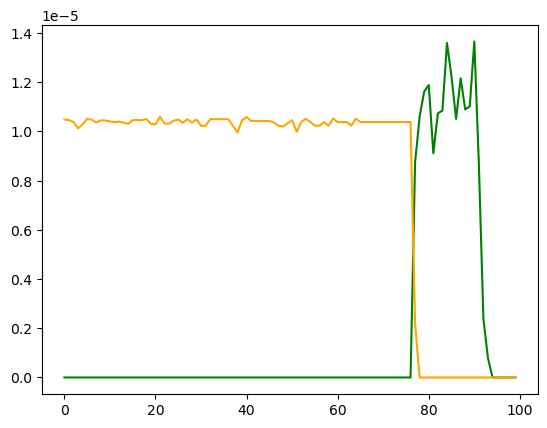

In [26]:
energy_mais = [results_cycle['agg'][t].loc[0, 'Energy'] for t in range(nb_samples)]
plt.plot(range(nb_samples), energy_mais, color='green')
energy_ble = [sum([results_cycle['agg'][t].loc[i, 'Energy'] for i in range(1,10)]) for t in range(nb_samples)]
plt.plot(range(nb_samples), energy_ble, color='orange')
plt.show()

In [ ]:
results = {}
ds = [150,160,170,180,190,200]
for delta_sowing in ds:
    results_cycle = simulation_cycle(jours_ble, jours_mais, delta_sowing, growing_ble, growing_mais, positions, domain, lights, nb_samples)
    results[delta_sowing] = results_cycle

In [ ]:
# sc, v=results_cycle['cs'][8].plot(results_cycle['raw'][8])

In [ ]:
fig, axes = plt.subplot(3,2)

for i,delta_sowing in enumerate(ds):
    energy_mais = [results[ds]['agg'][t].loc[0, 'Energy'] for t in range(nb_samples)]
    axes[i].plot(range(nb_samples), energy_mais, color='green')
    energy_ble = [sum([results[ds]['agg'][t].loc[i, 'Energy'] for i in range(1,10)]) for t in range(nb_samples)]
    axes[i].plot(range(nb_samples), energy_ble, color='orange')

plt.show()